In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import scipy.sparse as sp
from pathlib import Path

In [4]:
workdir = Path("D:/scRNA_benchmark/GSE132044")

mtx_path = workdir / "GSE132044_mixture_hg19_mm10_count_matrix.mtx.gz"
gene_path = workdir / "GSE132044_mixture_hg19_mm10_gene.tsv.gz"
cell_path = workdir / "GSE132044_mixture_hg19_mm10_cell.tsv.gz"

In [5]:
# 读取 count matrix
adata = sc.read_mtx(mtx_path).T   # 转置后变成 cell x gene

# 读取基因和细胞注释
genes = pd.read_csv(gene_path, sep="\t", header=None)
cells = pd.read_csv(cell_path, sep="\t", header=None)

print("矩阵维度:", adata.shape)
print("genes前5行:")
print(genes.head())
print("cells前5行:")
print(cells.head())

矩阵维度: (27714, 62046)
genes前5行:
                                    0
0    hg19_ENSG00000000003_hg19_TSPAN6
1      hg19_ENSG00000000005_hg19_TNMD
2      hg19_ENSG00000000419_hg19_DPM1
3     hg19_ENSG00000000457_hg19_SCYL3
4  hg19_ENSG00000000460_hg19_C1orf112
cells前5行:
                            0
0   Mixture1.Smart-seq2.p2_A4
1   Mixture1.Smart-seq2.p2_A7
2   Mixture1.Smart-seq2.p2_B1
3   Mixture1.Smart-seq2.p1_A7
4  Mixture1.Smart-seq2.p2_B12


In [6]:
# 第一列通常是 gene id 或 gene symbol
adata.var_names = genes.iloc[:, 0].astype(str).values

# 第一列通常是 cell barcode
adata.obs_names = cells.iloc[:, 0].astype(str).values

# 把 gene/cell 的全部信息都保留进去，后面慢慢看
for i in range(genes.shape[1]):
    adata.var[f"gene_col_{i}"] = genes.iloc[:, i].astype(str).values

for i in range(cells.shape[1]):
    adata.obs[f"cell_col_{i}"] = cells.iloc[:, i].astype(str).values

adata

AnnData object with n_obs × n_vars = 27714 × 62046
    obs: 'cell_col_0'
    var: 'gene_col_0'

In [7]:
adata.layers["counts"] = adata.X.copy()

In [8]:
print(adata.obs.head())
print(adata.var.head())
print("obs列名：", adata.obs.columns.tolist())
print("var列名：", adata.var.columns.tolist())

                                            cell_col_0
Mixture1.Smart-seq2.p2_A4    Mixture1.Smart-seq2.p2_A4
Mixture1.Smart-seq2.p2_A7    Mixture1.Smart-seq2.p2_A7
Mixture1.Smart-seq2.p2_B1    Mixture1.Smart-seq2.p2_B1
Mixture1.Smart-seq2.p1_A7    Mixture1.Smart-seq2.p1_A7
Mixture1.Smart-seq2.p2_B12  Mixture1.Smart-seq2.p2_B12
                                                            gene_col_0
hg19_ENSG00000000003_hg19_TSPAN6      hg19_ENSG00000000003_hg19_TSPAN6
hg19_ENSG00000000005_hg19_TNMD          hg19_ENSG00000000005_hg19_TNMD
hg19_ENSG00000000419_hg19_DPM1          hg19_ENSG00000000419_hg19_DPM1
hg19_ENSG00000000457_hg19_SCYL3        hg19_ENSG00000000457_hg19_SCYL3
hg19_ENSG00000000460_hg19_C1orf112  hg19_ENSG00000000460_hg19_C1orf112
obs列名： ['cell_col_0']
var列名： ['gene_col_0']


In [9]:
adata.var["mt"] = adata.var_names.str.upper().str.startswith("MT-")

In [10]:
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], inplace=True)
adata.obs.head()

,cell_col_0,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt
Mixture1.Smart-seq2.p2_A4,Mixture1.Smart-seq2.p2_A4,6415,8.766550,1081074.0,13.893467,20.973032,27.706799,36.402688,51.393244,0.0,0.0,0.0
Mixture1.Smart-seq2.p2_A7,Mixture1.Smart-seq2.p2_A7,6995,8.853094,1155198.0,13.959784,21.844048,29.179846,37.620737,51.683348,0.0,0.0,0.0
Mixture1.Smart-seq2.p2_B1,Mixture1.Smart-seq2.p2_B1,8111,9.001100,1225573.0,14.018920,19.677979,27.297191,36.123674,50.571773,0.0,0.0,0.0
Mixture1.Smart-seq2.p1_A7,Mixture1.Smart-seq2.p1_A7,4820,8.480737,1057363.0,13.871289,22.561410,29.591540,38.422093,54.245798,0.0,0.0,0.0
Mixture1.Smart-seq2.p2_B12,Mixture1.Smart-seq2.p2_B12,457,6.126869,182395.0,12.113935,61.462759,83.999013,99.168289,100.000000,0.0,0.0,0.0


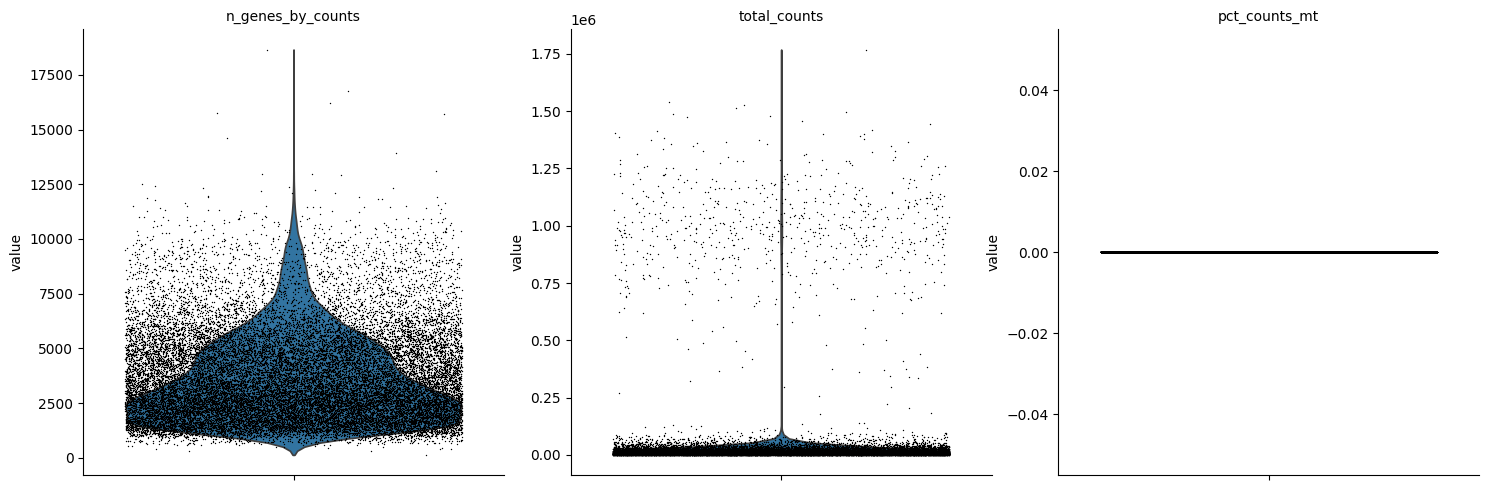

In [11]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True
)

In [12]:
adata = adata[adata.obs["n_genes_by_counts"] >= 200].copy()
adata = adata[adata.obs["pct_counts_mt"] <= 20].copy()
sc.pp.filter_genes(adata, min_cells=3)

print(adata.shape)

(27713, 44685)


In [13]:
target_n_cells = 5000

if adata.n_obs > target_n_cells:
    np.random.seed(1234)
    keep_idx = np.random.choice(adata.n_obs, target_n_cells, replace=False)
    adata = adata[keep_idx].copy()

print("下采样后维度:", adata.shape)

下采样后维度: (5000, 44685)


In [14]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.layers["lognorm"] = adata.X.copy()

3000


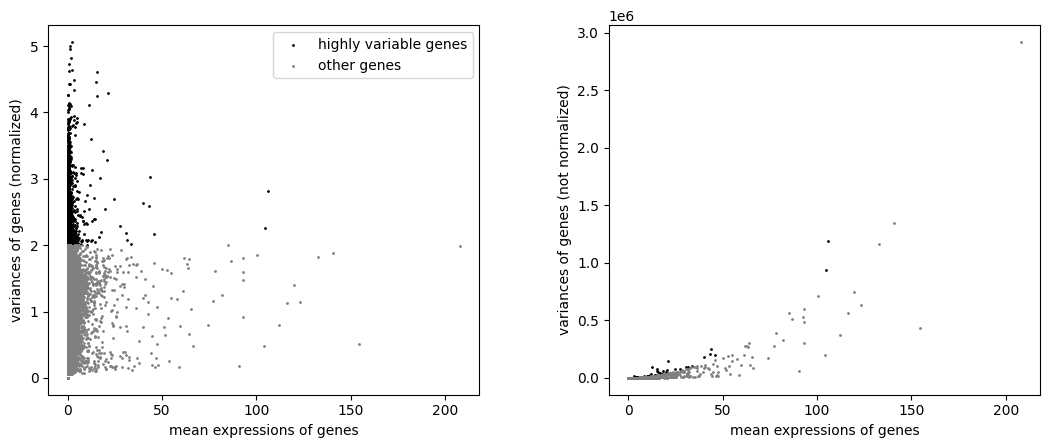

In [16]:
sc.pp.highly_variable_genes(adata, flavor="seurat_v3", n_top_genes=3000, layer="counts")
print(adata.var["highly_variable"].sum())
sc.pl.highly_variable_genes(adata)

In [17]:
adata = adata[:, adata.var["highly_variable"]].copy()
print(adata.shape)

(5000, 3000)


c:\Users\寻风\AppData\Local\Programs\Python\Python312\Lib\functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


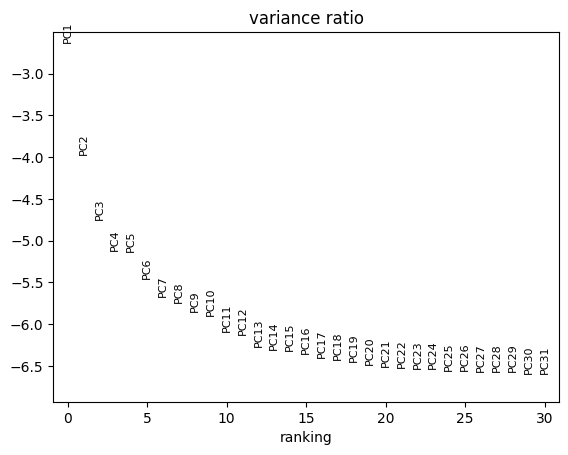

In [18]:
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, svd_solver="arpack")
sc.pl.pca_variance_ratio(adata, log=True)

In [22]:
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=30)

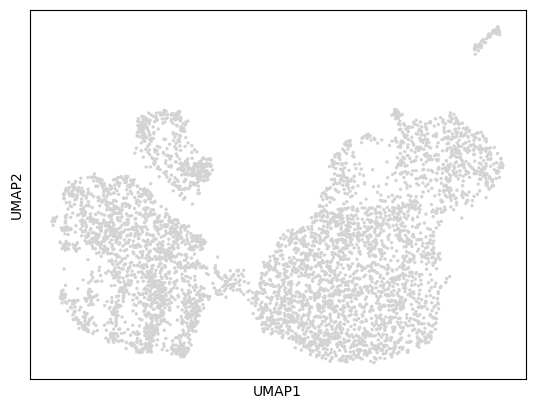

In [23]:
sc.tl.umap(adata)
sc.pl.umap(adata)

C:\Users\寻风\AppData\Local\Temp\ipykernel_34908\2276071930.py:1: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, resolution=0.5)


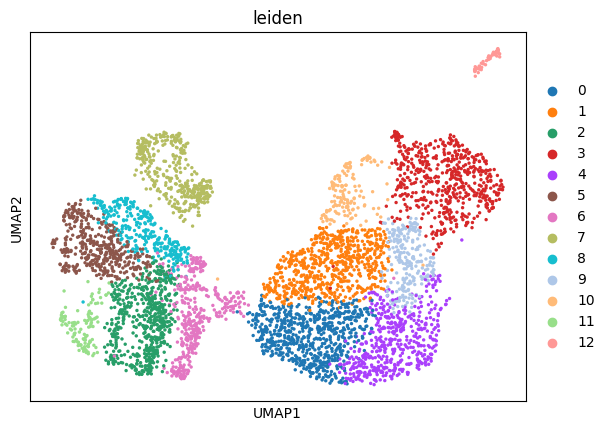

In [24]:
sc.tl.leiden(adata, resolution=0.5)
sc.pl.umap(adata, color=["leiden"])

In [25]:
adata.write_h5ad(workdir / "GSE132044_mixture_processed.h5ad")

In [27]:
print(cells.shape)
print(cells.head())

print(adata.obs.columns.tolist())
print(adata.obs.head())

(27714, 1)
                            0
0   Mixture1.Smart-seq2.p2_A4
1   Mixture1.Smart-seq2.p2_A7
2   Mixture1.Smart-seq2.p2_B1
3   Mixture1.Smart-seq2.p1_A7
4  Mixture1.Smart-seq2.p2_B12
['cell_col_0', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'leiden']
                                                                              cell_col_0  \
Mixture2.sci-RNA-seq.p1_D3-AACGTCTAGT              Mixture2.sci-RNA-seq.p1_D3-AACGTCTAGT   
Mixture2.inDrops.TGGACGGA-AAGAGCGT-AGCGTAGG  Mixture2.inDrops.TGGACGGA-AAGAGCGT-AGCGTAGG   
Mixture2.sci-RNA-seq.p1_A6-AGAGCCAGCC              Mixture2.sci-RNA-seq.p1_A6-AGAGCCAGCC   
Mixture1.Drop-seq.AAGCACGCTCGA                            Mixture1.Drop-seq.AAGCACGCTCGA   
Mixture2.inDrops.GCGTGCAA-AAGAGCGT-TTAGTCCG  Mixture2.

In [30]:
# 拆分 cell barcode 中的信息
tmp = adata.obs["cell_col_0"].str.split(".", expand=True)

adata.obs["mixture"] = tmp[0]

if tmp.shape[1] > 1:
    adata.obs["platform"] = tmp[1]

if tmp.shape[1] > 2:
    adata.obs["sub_id"] = tmp[2]

# 先临时把 mixture 作为 condition，用于跑通流程
adata.obs["condition"] = adata.obs["mixture"].copy()

print(adata.obs[["cell_col_0", "mixture", "platform", "condition"]].head(10))
print("\ncondition 计数：")
print(adata.obs["condition"].value_counts())

                                                                              cell_col_0  \
Mixture2.sci-RNA-seq.p1_D3-AACGTCTAGT              Mixture2.sci-RNA-seq.p1_D3-AACGTCTAGT   
Mixture2.inDrops.TGGACGGA-AAGAGCGT-AGCGTAGG  Mixture2.inDrops.TGGACGGA-AAGAGCGT-AGCGTAGG   
Mixture2.sci-RNA-seq.p1_A6-AGAGCCAGCC              Mixture2.sci-RNA-seq.p1_A6-AGAGCCAGCC   
Mixture1.Drop-seq.AAGCACGCTCGA                            Mixture1.Drop-seq.AAGCACGCTCGA   
Mixture2.inDrops.GCGTGCAA-AAGAGCGT-TTAGTCCG  Mixture2.inDrops.GCGTGCAA-AAGAGCGT-TTAGTCCG   
Mixture2.sci-RNA-seq.p2_H7-AGAGAAGGTT              Mixture2.sci-RNA-seq.p2_H7-AGAGAAGGTT   
Mixture1.Drop-seq.CTTCCGCTACAA                            Mixture1.Drop-seq.CTTCCGCTACAA   
Mixture2.Smart-seq2.p3_A8                                      Mixture2.Smart-seq2.p3_A8   
Mixture1.Seq-Well.GTTTTTATTCCG                            Mixture1.Seq-Well.GTTTTTATTCCG   
Mixture1.Seq-Well.CCGGGATGTGCC                            Mixture1.Seq-Well.CCGG

In [31]:
tmp_adata = adata[adata.obs["condition"].isin(["Mixture1", "Mixture2"])].copy()
tmp_adata.obs["condition"] = pd.Categorical(
    tmp_adata.obs["condition"],
    categories=["Mixture2", "Mixture1"]
)

tmp_adata.X = tmp_adata.layers["lognorm"].copy()

sc.tl.rank_genes_groups(
    tmp_adata,
    groupby="condition",
    groups=["Mixture2"],
    reference="Mixture1",
    method="wilcoxon",
    corr_method="benjamini-hochberg",
    tie_correct=True,
    pts=True
)

res_wil = sc.get.rank_genes_groups_df(tmp_adata, group="Mixture2")
res_wil.head()

,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group
0,hg19_ENSG00000135069_hg19_PSAT1,18.063911,1.644789,6.131938e-73,3.679163e-70,0.455817
1,hg19_ENSG00000156508_hg19_EEF1A1,15.047606,1.396194,3.579526e-51,5.965877e-49,0.523030
2,hg19_ENSG00000128965_hg19_CHAC1,14.126894,3.075842,2.593329e-45,3.241662e-43,0.127260
3,hg19_ENSG00000197714_hg19_ZNF460,13.714868,2.064382,8.271692e-43,8.862527e-41,0.185261
4,hg19_ENSG00000006652_hg19_IFRD1,13.345096,1.253323,1.265077e-40,1.116244e-38,0.353804


显著差异基因数: 1332


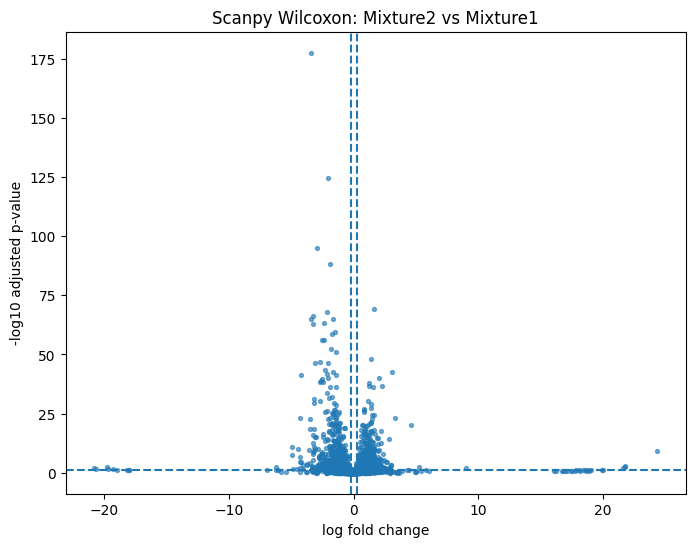

,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group
2999,mm10_ENSMUSG00000021250_mm10_Fos,-28.754501,-3.435052,7.956808e-182,2.387042e-178,0.128625
2998,mm10_ENSMUSG00000019929_mm10_Dcn,-24.110769,-2.083493,1.927355e-128,2.891033e-125,0.403275
2997,mm10_ENSMUSG00000024190_mm10_Dusp1,-21.072824,-2.931036,1.412512e-98,1.412512e-95,0.093142
2996,mm10_ENSMUSG00000038418_mm10_Egr1,-20.311583,-1.881231,1.015763e-91,7.618221e-89,0.279768
0,hg19_ENSG00000135069_hg19_PSAT1,18.063911,1.644789,6.131938e-73,3.679163e-70,0.455817
2995,mm10_ENSMUSG00000025268_mm10_Maged2,-17.860933,-2.149494,2.376301e-71,1.188150e-68,0.139884
2994,mm10_ENSMUSG00000022032_mm10_Scara5,-17.644617,-3.247358,1.119308e-69,4.797035e-67,0.031047
2993,mm10_ENSMUSG00000048387_mm10_Osr1,-17.451859,-1.647292,3.332085e-68,1.249532e-65,0.291709
2992,mm10_ENSMUSG00000026628_mm10_Atf3,-17.431597,-3.451192,4.750112e-68,1.583371e-65,0.021494
2991,mm10_ENSMUSG00000000031_mm10_H19,-17.215458,-2.411748,2.033338e-66,6.100013e-64,0.108495


In [32]:
deg_wil = res_wil.copy()

deg_wil_sig = deg_wil[
    (deg_wil["pvals_adj"] < 0.05) &
    (deg_wil["logfoldchanges"].abs() > 0.25)
].copy()

print("显著差异基因数:", deg_wil_sig.shape[0])
deg_wil_sig.head(20)
deg_wil_sig.to_csv(workdir / "scanpy_wilcoxon_sig_DEGs.csv", index=False)
import matplotlib.pyplot as plt
import numpy as np

plot_df = res_wil.copy()
plot_df["neglog10_padj"] = -np.log10(plot_df["pvals_adj"] + 1e-300)

plt.figure(figsize=(8,6))
plt.scatter(
    plot_df["logfoldchanges"],
    plot_df["neglog10_padj"],
    s=8,
    alpha=0.6
)

# 阈值线
plt.axvline(0.25, linestyle="--")
plt.axvline(-0.25, linestyle="--")
plt.axhline(-np.log10(0.05), linestyle="--")

plt.xlabel("log fold change")
plt.ylabel("-log10 adjusted p-value")
plt.title("Scanpy Wilcoxon: Mixture2 vs Mixture1")
plt.show()
res_wil.sort_values(["pvals_adj", "logfoldchanges"], ascending=[True, False]).head(20)

In [33]:
tmp_adata = adata[adata.obs["condition"].isin(["Mixture1", "Mixture2"])].copy()
tmp_adata.obs["condition"] = pd.Categorical(
    tmp_adata.obs["condition"],
    categories=["Mixture2", "Mixture1"]
)

tmp_adata.X = tmp_adata.layers["lognorm"].copy()

sc.tl.rank_genes_groups(
    tmp_adata,
    groupby="condition",
    groups=["Mixture2"],
    reference="Mixture1",
    method="t-test",
    corr_method="benjamini-hochberg",
    pts=True
)

res_t = sc.get.rank_genes_groups_df(tmp_adata, group="Mixture2")
res_t.to_csv(workdir / "scanpy_ttest_result.csv", index=False)
res_t.head()
adata.write_h5ad(workdir / "GSE132044_mixture_processed_with_condition.h5ad")

In [34]:
adata.var["gene_name_full"] = adata.var_names.astype(str)

adata.var["species"] = np.where(
    adata.var["gene_name_full"].str.startswith("hg19_"), "human",
    np.where(adata.var["gene_name_full"].str.startswith("mm10_"), "mouse", "unknown")
)

print(adata.var["species"].value_counts())
res_wil["species"] = np.where(
    res_wil["names"].str.startswith("hg19_"), "human",
    np.where(res_wil["names"].str.startswith("mm10_"), "mouse", "unknown")
)

print(res_wil["species"].value_counts())
res_wil.head()
res_t["species"] = np.where(
    res_t["names"].str.startswith("hg19_"), "human",
    np.where(res_t["names"].str.startswith("mm10_"), "mouse", "unknown")
)

print(res_t["species"].value_counts())
res_t.head()
res_wil_human = res_wil[res_wil["species"] == "human"].copy()
res_wil_mouse = res_wil[res_wil["species"] == "mouse"].copy()

print("Wilcoxon human top:")
print(res_wil_human.head(10))

print("\nWilcoxon mouse top:")
print(res_wil_mouse.head(10))
res_t_human = res_t[res_t["species"] == "human"].copy()
res_t_mouse = res_t[res_t["species"] == "mouse"].copy()

print("t-test human top:")
print(res_t_human.head(10))

print("\nt-test mouse top:")
print(res_t_mouse.head(10))

species
mouse    2306
human     694
Name: count, dtype: int64
species
mouse    2306
human     694
Name: count, dtype: int64
species
mouse    2306
human     694
Name: count, dtype: int64
Wilcoxon human top:
                                names     scores  logfoldchanges  \
0     hg19_ENSG00000135069_hg19_PSAT1  18.063911        1.644789   
1    hg19_ENSG00000156508_hg19_EEF1A1  15.047606        1.396194   
2     hg19_ENSG00000128965_hg19_CHAC1  14.126894        3.075842   
3    hg19_ENSG00000197714_hg19_ZNF460  13.714868        2.064382   
4     hg19_ENSG00000006652_hg19_IFRD1  13.345096        1.253323   
5   hg19_ENSG00000157514_hg19_TSC22D3  13.129115        2.262860   
6   hg19_ENSG00000112308_hg19_C6orf62  13.129086        1.198570   
8     hg19_ENSG00000113161_hg19_HMGCR  11.924216        1.124306   
9    hg19_ENSG00000213965_hg19_NUDT19  11.728194        1.428459   
11     hg19_ENSG00000135821_hg19_GLUL  11.253678        0.796339   

           pvals     pvals_adj  pct_nz_group 

In [35]:
top_n = 50

wil_top50 = set(res_wil["names"].head(top_n))
ttop50 = set(res_t["names"].head(top_n))

overlap = wil_top50 & ttop50

print("Wilcoxon top50 数量:", len(wil_top50))
print("t-test top50 数量:", len(ttop50))
print("重合基因数:", len(overlap))
print("\n部分重合基因：")
print(list(overlap)[:20])

Wilcoxon top50 数量: 50
t-test top50 数量: 50
重合基因数: 44

部分重合基因：
['mm10_ENSMUSG00000073530_mm10_Pappa2', 'hg19_ENSG00000197822_hg19_OCLN', 'hg19_ENSG00000256771_hg19_ZNF253', 'hg19_ENSG00000092964_hg19_DPYSL2', 'hg19_ENSG00000102024_hg19_PLS3', 'hg19_ENSG00000113161_hg19_HMGCR', 'mm10_ENSMUSG00000108532_mm10_RP23-231J2.1', 'hg19_ENSG00000073969_hg19_NSF', 'hg19_ENSG00000213965_hg19_NUDT19', 'hg19_ENSG00000131725_hg19_WDR44', 'hg19_ENSG00000070669_hg19_ASNS', 'hg19_ENSG00000006652_hg19_IFRD1', 'hg19_ENSG00000162290_hg19_DCP1A', 'hg19_ENSG00000087586_hg19_AURKA', 'hg19_ENSG00000170312_hg19_CDK1', 'hg19_ENSG00000172728_hg19_FUT10', 'mm10_ENSMUSG00000027955_mm10_Fam198b', 'hg19_ENSG00000105186_hg19_ANKRD27', 'mm10_ENSMUSG00000029816_mm10_Gpnmb', 'hg19_ENSG00000170540_hg19_ARL6IP1']


In [36]:
split_df = adata.obs["cell_col_0"].str.split(".", expand=True)

print(split_df.head(20))
print("拆分后的列数：", split_df.shape[1])

for i in range(split_df.shape[1]):
    adata.obs[f"split_{i}"] = split_df[i]

print(adata.obs[[f"split_{i}" for i in range(split_df.shape[1])]].head(20))

                                                    0                1  \
Mixture2.sci-RNA-seq.p1_D3-AACGTCTAGT        Mixture2      sci-RNA-seq   
Mixture2.inDrops.TGGACGGA-AAGAGCGT-AGCGTAGG  Mixture2          inDrops   
Mixture2.sci-RNA-seq.p1_A6-AGAGCCAGCC        Mixture2      sci-RNA-seq   
Mixture1.Drop-seq.AAGCACGCTCGA               Mixture1         Drop-seq   
Mixture2.inDrops.GCGTGCAA-AAGAGCGT-TTAGTCCG  Mixture2          inDrops   
Mixture2.sci-RNA-seq.p2_H7-AGAGAAGGTT        Mixture2      sci-RNA-seq   
Mixture1.Drop-seq.CTTCCGCTACAA               Mixture1         Drop-seq   
Mixture2.Smart-seq2.p3_A8                    Mixture2       Smart-seq2   
Mixture1.Seq-Well.GTTTTTATTCCG               Mixture1         Seq-Well   
Mixture1.Seq-Well.CCGGGATGTGCC               Mixture1         Seq-Well   
Mixture1.Drop-seq.AAGGACTAATAG               Mixture1         Drop-seq   
Mixture2.10x-Chromium-v2.CTTAACTCAAGCGTAG    Mixture2  10x-Chromium-v2   
Mixture1.inDrops.GAATCCCA-TATCCTCT-CTA

In [37]:
print(adata.obs["split_2"].head(30))

Mixture2.sci-RNA-seq.p1_D3-AACGTCTAGT                    p1_D3-AACGTCTAGT
Mixture2.inDrops.TGGACGGA-AAGAGCGT-AGCGTAGG    TGGACGGA-AAGAGCGT-AGCGTAGG
Mixture2.sci-RNA-seq.p1_A6-AGAGCCAGCC                    p1_A6-AGAGCCAGCC
Mixture1.Drop-seq.AAGCACGCTCGA                               AAGCACGCTCGA
Mixture2.inDrops.GCGTGCAA-AAGAGCGT-TTAGTCCG    GCGTGCAA-AAGAGCGT-TTAGTCCG
Mixture2.sci-RNA-seq.p2_H7-AGAGAAGGTT                    p2_H7-AGAGAAGGTT
Mixture1.Drop-seq.CTTCCGCTACAA                               CTTCCGCTACAA
Mixture2.Smart-seq2.p3_A8                                           p3_A8
Mixture1.Seq-Well.GTTTTTATTCCG                               GTTTTTATTCCG
Mixture1.Seq-Well.CCGGGATGTGCC                               CCGGGATGTGCC
Mixture1.Drop-seq.AAGGACTAATAG                               AAGGACTAATAG
Mixture2.10x-Chromium-v2.CTTAACTCAAGCGTAG                CTTAACTCAAGCGTAG
Mixture1.inDrops.GAATCCCA-TATCCTCT-CTACCGTT    GAATCCCA-TATCCTCT-CTACCGTT
Mixture1.10x-Chromium-v2.CGGGTCATCACCC

In [38]:
# 1. 从之前拆分结果中正式命名
adata.obs["condition"] = adata.obs["split_0"].astype(str)
adata.obs["platform"] = adata.obs["split_1"].astype(str)
adata.obs["raw_id"] = adata.obs["split_2"].astype(str)

# 2. 针对不同平台，构建 sample_id
# Smart-seq2 / sci-RNA-seq 常带 p1/p2/p3 这种 pool/plate 信息
adata.obs["pool"] = adata.obs["raw_id"].str.extract(r'^(p\d+)')[0]

# 3. 如果没有 pool，则先用 platform + mixture 作为粗略 sample
adata.obs["sample"] = np.where(
    adata.obs["pool"].notna(),
    adata.obs["condition"] + "_" + adata.obs["platform"] + "_" + adata.obs["pool"],
    adata.obs["condition"] + "_" + adata.obs["platform"]
)

# 4. 看一下结果
print(adata.obs[["cell_col_0", "condition", "platform", "raw_id", "pool", "sample"]].head(20))

                                                                              cell_col_0  \
Mixture2.sci-RNA-seq.p1_D3-AACGTCTAGT              Mixture2.sci-RNA-seq.p1_D3-AACGTCTAGT   
Mixture2.inDrops.TGGACGGA-AAGAGCGT-AGCGTAGG  Mixture2.inDrops.TGGACGGA-AAGAGCGT-AGCGTAGG   
Mixture2.sci-RNA-seq.p1_A6-AGAGCCAGCC              Mixture2.sci-RNA-seq.p1_A6-AGAGCCAGCC   
Mixture1.Drop-seq.AAGCACGCTCGA                            Mixture1.Drop-seq.AAGCACGCTCGA   
Mixture2.inDrops.GCGTGCAA-AAGAGCGT-TTAGTCCG  Mixture2.inDrops.GCGTGCAA-AAGAGCGT-TTAGTCCG   
Mixture2.sci-RNA-seq.p2_H7-AGAGAAGGTT              Mixture2.sci-RNA-seq.p2_H7-AGAGAAGGTT   
Mixture1.Drop-seq.CTTCCGCTACAA                            Mixture1.Drop-seq.CTTCCGCTACAA   
Mixture2.Smart-seq2.p3_A8                                      Mixture2.Smart-seq2.p3_A8   
Mixture1.Seq-Well.GTTTTTATTCCG                            Mixture1.Seq-Well.GTTTTTATTCCG   
Mixture1.Seq-Well.CCGGGATGTGCC                            Mixture1.Seq-Well.CCGG

In [39]:
print("condition 分布：")
print(adata.obs["condition"].value_counts())

print("\nplatform 分布：")
print(adata.obs["platform"].value_counts())

print("\nsample 分布（前20个）：")
print(adata.obs["sample"].value_counts().head(20))

print("\n总 sample 数：", adata.obs["sample"].nunique())

condition 分布：
condition
Mixture2    2931
Mixture1    2069
Name: count, dtype: int64

platform 分布：
platform
Drop-seq           1153
10x-Chromium-v2    1132
inDrops            1042
sci-RNA-seq         966
Seq-Well            458
CEL-Seq2            130
Smart-seq2          119
Name: count, dtype: int64

sample 分布（前20个）：
sample
Mixture2_Drop-seq           686
Mixture1_inDrops            579
Mixture2_10x-Chromium-v2    573
Mixture1_10x-Chromium-v2    559
Mixture1_Drop-seq           467
Mixture2_sci-RNA-seq_p2     466
Mixture2_inDrops            463
Mixture2_sci-RNA-seq_p1     440
Mixture1_Seq-Well           284
Mixture2_Seq-Well           174
Mixture1_CEL-Seq2            65
Mixture2_CEL-Seq2            65
Mixture1_sci-RNA-seq         60
Mixture2_Smart-seq2_p2       19
Mixture1_Smart-seq2_p4       19
Mixture2_Smart-seq2_p3       18
Mixture1_Smart-seq2_p3       16
Mixture2_Smart-seq2_p4       14
Mixture2_Smart-seq2_p1       13
Mixture1_Smart-seq2_p2       13
Name: count, dtype: int64

总 sampl

In [40]:
import scipy.sparse as sp
import pandas as pd
import numpy as np

# 用原始 counts 做 pseudo-bulk
counts = adata.layers["counts"]
if sp.issparse(counts):
    counts = counts.tocsr()

sample_ids = adata.obs["sample"].values
unique_samples = pd.unique(sample_ids)

pb_mat = []
pb_obs = []

for sid in unique_samples:
    idx = np.where(sample_ids == sid)[0]
    if len(idx) == 0:
        continue
    
    sub_counts = counts[idx]
    summed = np.asarray(sub_counts.sum(axis=0)).ravel()
    pb_mat.append(summed)
    
    pb_obs.append({
        "sample": sid,
        "condition": adata.obs.iloc[idx[0]]["condition"],
        "platform": adata.obs.iloc[idx[0]]["platform"],
        "n_cells": len(idx)
    })

pb_mat = np.vstack(pb_mat)
pb_obs = pd.DataFrame(pb_obs)
pb_var = pd.DataFrame(index=adata.var_names)

print("pseudo-bulk matrix shape:", pb_mat.shape)
print(pb_obs.head())

pseudo-bulk matrix shape: (21, 3000)
                    sample condition     platform  n_cells
0  Mixture2_sci-RNA-seq_p1  Mixture2  sci-RNA-seq      440
1         Mixture2_inDrops  Mixture2      inDrops      463
2        Mixture1_Drop-seq  Mixture1     Drop-seq      467
3  Mixture2_sci-RNA-seq_p2  Mixture2  sci-RNA-seq      466
4   Mixture2_Smart-seq2_p3  Mixture2   Smart-seq2       18


In [41]:
pb_counts_df = pd.DataFrame(pb_mat, index=pb_obs["sample"], columns=adata.var_names)

pb_counts_df.to_csv(workdir / "pseudobulk_counts.csv")
pb_obs.to_csv(workdir / "pseudobulk_metadata.csv", index=False)

print("已保存：")
print(workdir / "pseudobulk_counts.csv")
print(workdir / "pseudobulk_metadata.csv")

已保存：
D:\scRNA_benchmark\GSE132044\pseudobulk_counts.csv
D:\scRNA_benchmark\GSE132044\pseudobulk_metadata.csv


In [42]:
adata.write_h5ad(workdir / "GSE132044_mixture_with_metadata.h5ad")
adata.obs.to_csv(workdir / "cell_metadata_parsed.csv")

In [43]:
print(pb_obs)

                      sample condition         platform  n_cells
0    Mixture2_sci-RNA-seq_p1  Mixture2      sci-RNA-seq      440
1           Mixture2_inDrops  Mixture2          inDrops      463
2          Mixture1_Drop-seq  Mixture1         Drop-seq      467
3    Mixture2_sci-RNA-seq_p2  Mixture2      sci-RNA-seq      466
4     Mixture2_Smart-seq2_p3  Mixture2       Smart-seq2       18
5          Mixture1_Seq-Well  Mixture1         Seq-Well      284
6   Mixture2_10x-Chromium-v2  Mixture2  10x-Chromium-v2      573
7           Mixture1_inDrops  Mixture1          inDrops      579
8   Mixture1_10x-Chromium-v2  Mixture1  10x-Chromium-v2      559
9     Mixture2_Smart-seq2_p1  Mixture2       Smart-seq2       13
10         Mixture2_Drop-seq  Mixture2         Drop-seq      686
11         Mixture2_Seq-Well  Mixture2         Seq-Well      174
12      Mixture1_sci-RNA-seq  Mixture1      sci-RNA-seq       60
13    Mixture1_Smart-seq2_p4  Mixture1       Smart-seq2       19
14         Mixture2_CEL-S

In [44]:
pb_obs_filt = pb_obs[pb_obs["n_cells"] >= 20].copy()
keep_samples = pb_obs_filt["sample"].tolist()

pb_counts_df_filt = pb_counts_df.loc[keep_samples].copy()

print(pb_obs_filt)
print("\n过滤后 pseudo-bulk matrix shape:", pb_counts_df_filt.shape)
pb_counts_df_filt.to_csv(workdir / "pseudobulk_counts_filtered.csv")
pb_obs_filt.to_csv(workdir / "pseudobulk_metadata_filtered.csv", index=False)

                      sample condition         platform  n_cells
0    Mixture2_sci-RNA-seq_p1  Mixture2      sci-RNA-seq      440
1           Mixture2_inDrops  Mixture2          inDrops      463
2          Mixture1_Drop-seq  Mixture1         Drop-seq      467
3    Mixture2_sci-RNA-seq_p2  Mixture2      sci-RNA-seq      466
5          Mixture1_Seq-Well  Mixture1         Seq-Well      284
6   Mixture2_10x-Chromium-v2  Mixture2  10x-Chromium-v2      573
7           Mixture1_inDrops  Mixture1          inDrops      579
8   Mixture1_10x-Chromium-v2  Mixture1  10x-Chromium-v2      559
10         Mixture2_Drop-seq  Mixture2         Drop-seq      686
11         Mixture2_Seq-Well  Mixture2         Seq-Well      174
12      Mixture1_sci-RNA-seq  Mixture1      sci-RNA-seq       60
14         Mixture2_CEL-Seq2  Mixture2         CEL-Seq2       65
15         Mixture1_CEL-Seq2  Mixture1         CEL-Seq2       65

过滤后 pseudo-bulk matrix shape: (13, 3000)
